## LABORATORIO 06

Grupo N2

Pedro Jhoel Antonio Magne Ordoñez

Dafne July Gomez Garcia Flores

In [130]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

In [131]:
# ==============================
# 🔹 1. IMPORTACIONES
# ==============================
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# 🔹 2. CARGA Y UNIÓN
# ==============================
path = r'D:/Universidad/5to Semestre/Inteligencia Artificial/git/Datasets Preparados/D9 Meningitis Dataset with Missing Values/medical_risk_full.csv '
df = pd.read_csv(path)

# ==============================
# 🔹 3. VARIABLES NUMÉRICAS
# ==============================
nums = [
    "Age", 
    "WBC_Count",
    "Protein_Level",
    "Glucose_Level",
    "Hemoglobin",
    "WBC_Blood_Count",
    "Platelets",
    "CRP_Level",
    "Gender_Male",
    "Pathogen_Present_Yes",
    "Diagnosis_Unknown",
    "Diagnosis_Viral",
    "Outcome_Recovered"
]

# Verificar columnas existentes
for col in nums + ['Risk_Level']:
    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el dataset")

# ==============================
# 🔹 4. LIMPIEZA BÁSICA
# ==============================
# Convertir a numérico por seguridad
df[nums] = df[nums].apply(pd.to_numeric, errors='coerce')

# Reemplazar NaN
df[nums] = df[nums].fillna(df[nums].mean())

# ==============================
# 🔹 5. BALANCEO MULTICLASE
# ==============================
df_low = df[df['Risk_Level'] == 0]
df_mid = df[df['Risk_Level'] == 1]
df_high = df[df['Risk_Level'] == 2]

min_muestras = min(len(df_low), len(df_mid), len(df_high))
print(f"Balanceando a {min_muestras} muestras por nivel de riesgo...")

df_bal = pd.concat([
    df_low.sample(n=min_muestras, random_state=42),
    df_mid.sample(n=min_muestras, random_state=42),
    df_high.sample(n=min_muestras, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# ==============================
# 🔹 6. PREPARACIÓN DE X e Y
# ==============================
X_df = df_bal[nums]   # ✅ SOLO columnas numéricas definidas
y = df_bal['Risk_Level'].astype(int).values

# ==============================
# 🔹 7. NORMALIZACIÓN
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# ==============================
# 🔹 8. SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# 🔹 9. VERIFICACIÓN FINAL
# ==============================
print("\n✅ Preparación Médica Completada:")
print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")
print(f"Distribución entrenamiento: {np.bincount(y_train)}")
print(f"Distribución prueba: {np.bincount(y_test)}")

Balanceando a 137 muestras por nivel de riesgo...

✅ Preparación Médica Completada:
Entrenamiento: 328 registros
Prueba: 83 registros
Distribución entrenamiento: [110 109 109]
Distribución prueba: [27 28 28]


In [132]:
class DatasetMulticlase(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [133]:
train_dataset = DatasetMulticlase(X_train, y_train)
test_dataset = DatasetMulticlase(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [134]:
print("Número de features:", X_train.shape[1])

Número de features: 13


## Regularización:

Para asegurar que nuestro modelo generalice correctamente y no se limite a memorizar los datos de entrenamiento, hemos implementado dos técnicas de regularización:

Dropout: Introducimos capas nn.Dropout. Esta técnica apaga aleatoriamente un porcentaje de neuronas durante cada paso del entrenamiento, evitando que la red dependa excesivamente de neuronas específicas y forzándola a aprender representaciones más globales.

Weight Decay (L2): Aplicada directamente en el optimizador, penaliza los pesos de la red que crecen demasiado. Esto mantiene la complejidad del modelo bajo control y suaviza la función de decisión.

## Optimización de la Arquitectura: Batch Normalization

Para acelerar la convergencia y estabilizar el aprendizaje, añadimos capas de Batch Normalization después de cada capa lineal.

Esta técnica normaliza las activaciones de la red para que tengan media cero y varianza unitaria en cada lote (batch).

Beneficio: Permite usar tasas de aprendizaje (Learning Rates) más altas y reduce la sensibilidad a la inicialización de los pesos, haciendo que el entrenamiento sea mucho más robusto.

In [135]:
class MedicalClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=3, dropout_p=0.3):
        super().__init__()
        # Definimos la estructura de la red
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), # Optimización
            nn.ReLU(),
            nn.Dropout(dropout_p),      # Regularización
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), # Optimización
            nn.ReLU(),
            nn.Dropout(dropout_p),           # Regularización
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

input_size = X_train.shape[1]
model = MedicalClassifier(input_dim=input_size, dropout_p=0.3)

## Ajuste Dinámico: Learning Rate Scheduler

No siempre es óptimo mantener la misma velocidad de aprendizaje durante todo el entrenamiento.

Utilizamos ReduceLROnPlateau, un planificador que monitorea la pérdida de validación.

Si el error deja de bajar durante un número determinado de épocas (patience), el scheduler reduce automáticamente el Learning Rate. Esto permite que el modelo pula los detalles finales y encuentre un mínimo de error más preciso.

In [136]:
input_size = X_train.shape[1]
model = MedicalClassifier(input_dim=input_size, dropout_p=0.3)

criterion = nn.CrossEntropyLoss()
# El weight_decay es la regularización L2
# # Usamos Adam con los parámetros sugeridos en el cuadernillo
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

# Optimización: Scheduler (Reduce el LR si la val_loss no baja en 10 épocas)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [137]:
def train_model(model, train_loader, val_loader, epochs=100):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_loss = float('inf')  # Inicializamos con un valor infinito
    
    for epoch in range(1, epochs + 1):
        # Fase de Entrenamiento
        model.train()
        t_loss, t_acc = 0, 0
        for Xb, yb in train_loader:
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item()
            t_acc += (outputs.argmax(1) == yb).sum().item() / len(yb)
        
        # Fase de Validación
        model.eval()
        v_loss, v_acc = 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                outputs = model(Xb)
                loss = criterion(outputs, yb)
                v_loss += loss.item()
                v_acc += (outputs.argmax(1) == yb).sum().item() / len(yb)
        
        # Promedios de la época
        current_train_loss = t_loss / len(train_loader)
        current_val_loss = v_loss / len(val_loader)
        current_train_acc = t_acc / len(train_loader)
        current_val_acc = v_acc / len(val_loader)

        # OPTIMIZACIÓN: Guardar el mejor modelo (Checkpointing)
        if current_val_loss < best_loss:
            best_loss = current_val_loss
            torch.save(model.state_dict(), "mejor_modelo_multiclase.pt")
            # El mensaje solo se imprime si hay una mejora real
            if epoch % 10 == 0: 
                print(f"--- Época {epoch}: Nuevo mejor modelo guardado (Loss: {best_loss:.4f}) ---")

        # OPTIMIZACIÓN: Actualizar el scheduler
        scheduler.step(current_val_loss)
        
        # Guardar historial
        history['train_loss'].append(current_train_loss)
        history['val_loss'].append(current_val_loss)
        history['train_acc'].append(current_train_acc)
        history['val_acc'].append(current_val_acc)
        
        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch} | LR: {current_lr:.6f} | Train Loss: {current_train_loss:.4f} | Val Loss: {current_val_loss:.4f}")

    return history

# Ejecutar el entrenamiento
history = train_model(model, train_loader, test_loader, epochs=150)

Epoch 10 | LR: 0.010000 | Train Loss: 0.4686 | Val Loss: 0.4362
Epoch 20 | LR: 0.005000 | Train Loss: 0.3406 | Val Loss: 0.4963
Epoch 30 | LR: 0.002500 | Train Loss: 0.4143 | Val Loss: 0.4945
Epoch 40 | LR: 0.001250 | Train Loss: 0.2940 | Val Loss: 0.4783
Epoch 50 | LR: 0.001250 | Train Loss: 0.2733 | Val Loss: 0.4652
Epoch 60 | LR: 0.000625 | Train Loss: 0.2620 | Val Loss: 0.4722
Epoch 70 | LR: 0.000313 | Train Loss: 0.2607 | Val Loss: 0.4667
Epoch 80 | LR: 0.000156 | Train Loss: 0.2951 | Val Loss: 0.4683
Epoch 90 | LR: 0.000078 | Train Loss: 0.2765 | Val Loss: 0.4718
Epoch 100 | LR: 0.000039 | Train Loss: 0.2711 | Val Loss: 0.4944
Epoch 110 | LR: 0.000020 | Train Loss: 0.2621 | Val Loss: 0.4845
Epoch 120 | LR: 0.000010 | Train Loss: 0.4114 | Val Loss: 0.4760
Epoch 130 | LR: 0.000005 | Train Loss: 0.2508 | Val Loss: 0.4898
Epoch 140 | LR: 0.000002 | Train Loss: 0.2588 | Val Loss: 0.4881
Epoch 150 | LR: 0.000001 | Train Loss: 0.2586 | Val Loss: 0.4714


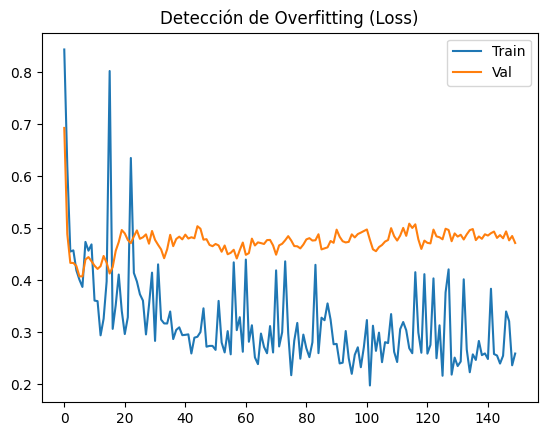

In [138]:
# history = train_model(...)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Detección de Overfitting (Loss)')
plt.legend()
plt.show()

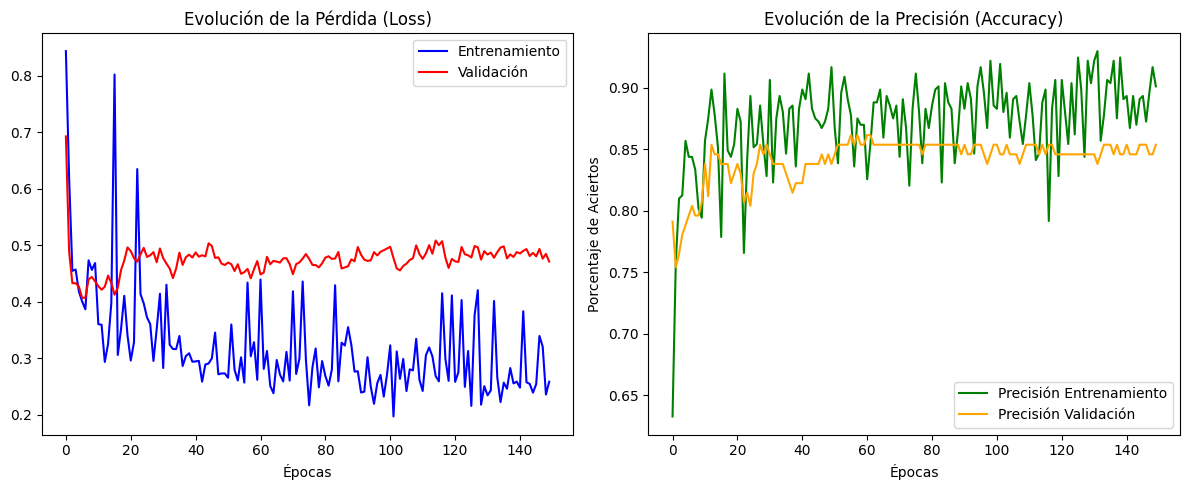

In [139]:
plt.figure(figsize=(12, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Entrenamiento', color='blue')
plt.plot(history['val_loss'], label='Validación', color='red')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.legend()

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Precisión Entrenamiento', color='green')
plt.plot(history['val_acc'], label='Precisión Validación', color='orange') # Añadimos validación
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje de Aciertos')
plt.legend()

plt.tight_layout()
plt.show()

In [140]:
# =================================================================
# 🔹 MÉTRICAS FINALES (Adaptadas al diccionario history)
# =================================================================

# Extraemos el último valor del historial
train_acc_final = history['train_acc'][-1] * 100
val_acc_final   = history['val_acc'][-1] * 100
train_loss_final = history['train_loss'][-1]
val_loss_final   = history['val_loss'][-1]

print(f"{'MÉTRICA':<20} | {'ENTRENAMIENTO':<15} | {'VALIDACIÓN':<15}")
print("-" * 55)
print(f"{'Precisión (Accuracy)':<20} | {train_acc_final:>13.2f}% | {val_acc_final:>13.2f}%")
print(f"{'Pérdida (Loss)':<20} | {train_loss_final:>13.4f}  | {val_loss_final:>13.4f}")

# Brecha de Generalización (Gap)
gap = train_acc_final - val_acc_final
print("-" * 55)
print(f"Brecha de Overfitting: {gap:.2f}%")

MÉTRICA              | ENTRENAMIENTO   | VALIDACIÓN     
-------------------------------------------------------
Precisión (Accuracy) |         90.10% |         85.36%
Pérdida (Loss)       |        0.2586  |        0.4714
-------------------------------------------------------
Brecha de Overfitting: 4.74%


In [141]:
tabla_precision = pd.DataFrame({
    "Tipo de Datos": ["Entrenamiento", "Prueba"],
    "Precisión (%)": [train_acc_final, val_acc_final]
})

In [142]:
tabla_precision.style.format({
    "Precisión (%)": "{:.2f}"
})

,Tipo de Datos,Precisión (%)
0,Entrenamiento,90.10
1,Prueba,85.36


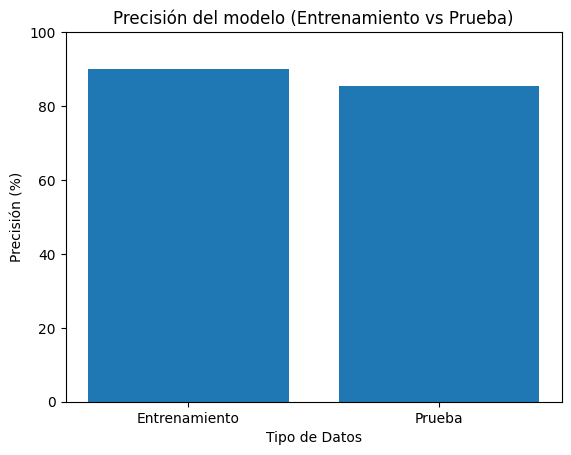

In [143]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(tabla_precision["Tipo de Datos"], tabla_precision["Precisión (%)"])
plt.title("Precisión del modelo (Entrenamiento vs Prueba)")
plt.ylabel("Precisión (%)")
plt.xlabel("Tipo de Datos")
plt.ylim(0, 100)
plt.show()

## Selección del Mejor Modelo (Checkpointing)
Durante las 150 épocas, es posible que el modelo alcance su punto óptimo antes de la última iteración.

Implementamos una lógica de Checkpointing que guarda los pesos del modelo (state_dict) únicamente cuando la pérdida de validación es la más baja registrada hasta el momento.

Al finalizar, cargamos estos pesos óptimos para garantizar que los resultados finales correspondan a la versión más equilibrada de la red.

In [144]:
model.load_state_dict(torch.load("mejor_modelo_multiclase.pt"))
model.eval()

MedicalClassifier(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [145]:
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

In [146]:
ejemplo = torch.tensor([X_test[0]], dtype=torch.float32)

with torch.no_grad():
    output = model(ejemplo)
    probs = torch.softmax(output, dim=1)
    clase = torch.argmax(probs).item()

print("Probabilidades:", probs.numpy())
print("Clase predicha:", clase)
print("Clase real:", y_test[0])

Probabilidades: [[0.08514965 0.8239119  0.0909384 ]]
Clase predicha: 1
Clase real: 1


## Evaluación de Métricas Multiclase

Para validar el rendimiento real de nuestro clasificador de riesgo médico, utilizamos métricas que van más allá de la precisión (Accuracy) simple:


Matriz de Confusión: Nos permite visualizar gráficamente los errores del modelo, identificando qué clases se están confundiendo entre sí (por ejemplo, si un riesgo "Bajo" es clasificado erróneamente como "Medio").

F1-Score: Es la media armónica entre la Precisión y el Recall. Es vital en este proyecto porque nos indica qué tan bien equilibra el modelo la detección de cada nivel de riesgo, especialmente si alguna clase tiene menos muestras que las demás.

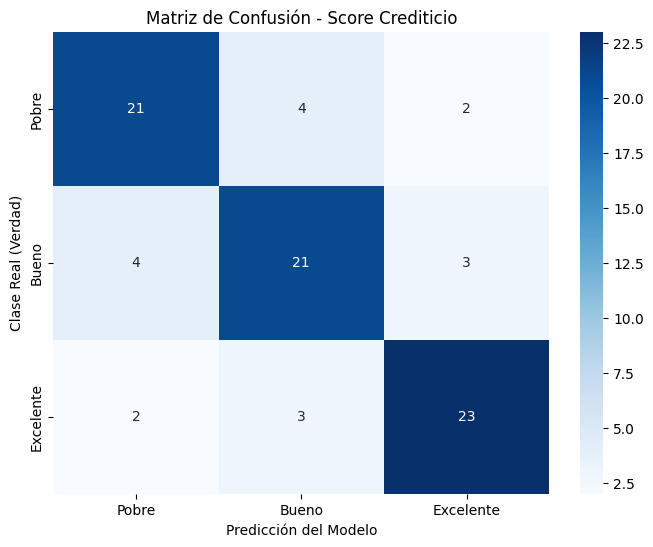


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

       Pobre       0.78      0.78      0.78        27
       Bueno       0.75      0.75      0.75        28
   Excelente       0.82      0.82      0.82        28

    accuracy                           0.78        83
   macro avg       0.78      0.78      0.78        83
weighted avg       0.78      0.78      0.78        83



In [147]:
# 1. Ponemos el modelo en modo evaluación
model.eval()

# 2. Realizamos las predicciones sobre todo el set de prueba
y_pred_list = []
y_true_list = []

with torch.no_grad():
    # Convertimos X_test a tensor
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    # Obtenemos las salidas de la red
    outputs = model(X_test_tensor)

    # torch.max nos da el índice de la clase con mayor probabilidad (0, 1 o 2)
    _, predicted = torch.max(outputs, 1)

    y_pred_list = predicted.numpy()
    y_true_list = y_test

# 3. Generamos la Matriz de Confusión
cm = confusion_matrix(y_true_list, y_pred_list)

# 4. Graficamos con Seaborn para que se vea profesional
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pobre', 'Bueno', 'Excelente'],
            yticklabels=['Pobre', 'Bueno', 'Excelente'])

plt.title('Matriz de Confusión - Score Crediticio')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Verdad)')
plt.show()

# 5. Imprimimos el reporte detallado (Precisión, Recall, F1-Score)
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_true_list, y_pred_list, target_names=['Pobre', 'Bueno', 'Excelente']))

## Evaluación de Discriminación: Curva ROC

La Curva ROC (Receiver Operating Characteristic) es una representación gráfica de la sensibilidad del modelo frente a la especificidad.

Eje Y (True Positive Rate): La capacidad del modelo para encontrar correctamente los casos positivos.

Eje X (False Positive Rate): La frecuencia con la que el modelo comete una falsa alarma.

AUC (Área Bajo la Curva): Es un valor entre 0 y 1. Un AUC de 0.5 significa que el modelo no es mejor que el azar, mientras que un AUC cercano a 1.0 indica una capacidad de clasificación casi perfecta.

Al ser un problema multiclase (Bajo, Medio y Alto Riesgo), calculamos la curva para cada clase de forma independiente (estrategia One-vs-Rest), lo que nos permite visualizar en qué niveles de riesgo el modelo es más confiable.

In [148]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

model.eval()

# Obtener probabilidades
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    outputs = model(X_test_tensor)
    y_score = torch.softmax(outputs, dim=1).numpy()

In [149]:
n_classes = 3
y_test_bin = label_binarize(y_test, classes=[0,1,2])

In [150]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

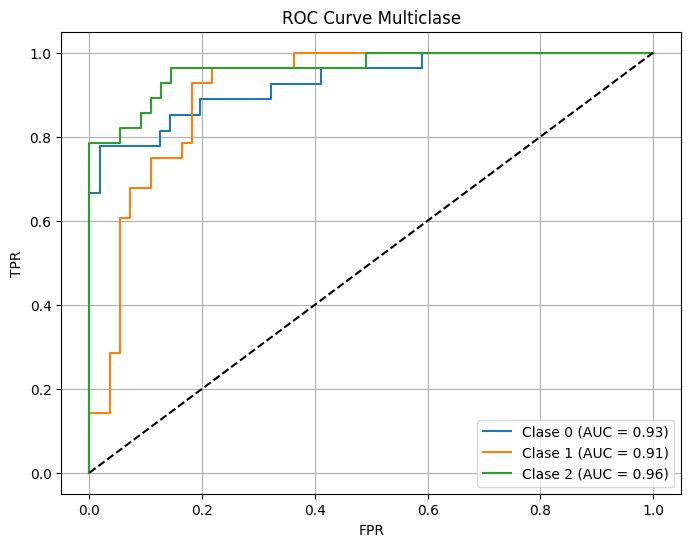

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve Multiclase')
plt.legend()
plt.grid()
plt.show()

In [152]:
from sklearn.metrics import roc_auc_score

auc_total = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("AUC global:", auc_total)

AUC global: 0.935734327400994


In [153]:
# ==============================
# 🔹 1. DataFrame con datos de prueba
# ==============================
df_test_visual = pd.DataFrame(X_test, columns=nums)
df_test_visual['label_real'] = y_test.astype(int)

# ==============================
# 🔹 2. Seleccionar ejemplos por clase
# ==============================
ejemplos_low = df_test_visual[df_test_visual['label_real'] == 0].head(3)
ejemplos_mid = df_test_visual[df_test_visual['label_real'] == 1].head(3)
ejemplos_high = df_test_visual[df_test_visual['label_real'] == 2].head(3)

# ==============================
# 🔹 3. Unir ejemplos
# ==============================
df_ejemplos = pd.concat([ejemplos_low, ejemplos_mid, ejemplos_high])

X_muestra = df_ejemplos[nums].values
y_muestra_real = df_ejemplos['label_real'].values

# ==============================
# 🔹 4. Predicción con el modelo
# ==============================
import torch

X_muestra_tensor = torch.tensor(X_muestra, dtype=torch.float32)

model.eval()
with torch.no_grad():
    outputs = model(X_muestra_tensor)
    _, predicciones = torch.max(outputs, 1)

# ==============================
# 🔹 5. Mostrar resultados
# ==============================
nombres_clases = {
    0: 'Low Risk',
    1: 'Mid Risk',
    2: 'High Risk'
}

print(f"{'CASO':<5} | {'CLASE REAL':<12} | {'PREDICCIÓN':<12} | {'ESTADO'}")
print("-" * 55)

for i in range(len(y_muestra_real)):
    real = int(y_muestra_real[i])
    pred = int(predicciones[i].item())
    status = "Correcto" if real == pred else "Incorrecto"

    print(f"{i+1:<5} | {nombres_clases[real]:<12} | {nombres_clases[pred]:<12} | {status}")

CASO  | CLASE REAL   | PREDICCIÓN   | ESTADO
-------------------------------------------------------
1     | Low Risk     | Mid Risk     | Incorrecto
2     | Low Risk     | Low Risk     | Correcto
3     | Low Risk     | Low Risk     | Correcto
4     | Mid Risk     | Mid Risk     | Correcto
5     | Mid Risk     | Mid Risk     | Correcto
6     | Mid Risk     | High Risk    | Incorrecto
7     | High Risk    | Mid Risk     | Incorrecto
8     | High Risk    | High Risk    | Correcto
9     | High Risk    | High Risk    | Correcto
